# Agentic AI For Research Purposes

### Import Necessary Libraries

In [3]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI


In [77]:
# Finding the .env key without showing it
load_dotenv()

# Set up AI Model
model = ChatOpenAI(
    model_name="gpt-3.5-turbo",
    temperature=0.7 # Temperature is a hyperparameter here - controls randomness
)

# Test if its working first 
response = model.invoke('Hey There! are u working?')
print(response.content)

Hello! I am an AI assistant and I am always working to help and assist you. How can I assist you today?


### Defining Workflow State and quick test to see if it works

In [5]:
# Ok now to define agents with LangGraph
"""
I want to create an agentic workflow that can search the web, find relevant data, get a first draft going, then review it and output a 
revised final draft 
"""

'\nI want to create an agentic workflow that can search the web, find relevant data, get a first draft going, then review it and output a \nrevised final draft \n'

In [56]:
# Defining State first
# I need 3 things for this to work State, Nodes and Edges

# What info can out agents write down
from typing import TypedDict, List

class WorkFlowState(TypedDict):
    initial_topic: str
    research_links : List[str]
    rough_draft : str
    final_draft : str

In [57]:
# Workers are called nodes in LangGraph
# Defining first agent here


from langchain_community.tools import DuckDuckGoSearchRun
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage # Packages as a human message


### Initializing our main tool - DuckDuckGo Search tool

In [58]:
# initialize our search tool and our chat model

search_tool = DuckDuckGoSearchRun()
model = ChatOpenAI(
    model_name="gpt-3.5-turbo",
    temperature=0.7
)

### Defining First Worker, or Research Agent

In [ ]:
# Defining our first node or worker

def researcher_agent(state: WorkFlowState):
    print('AGENT 1: RESEARCHER IS WORKING')

    # 1. Look at clipboard to see what topic the user wants
    topic = state['initial_topic']

    # 2. Use the search tool to find relevant links
    print('Searching the Web for relevant links')
    search_results = search_tool.run(topic)

    # 3. Ask the LLM to extract the top 5 key facts or URLs from those links

    prompt = f""" 
    You are an expert researcher. Based on these raw web search results about '{topic}', 
    extract a list of the top 3-5 most important points, facts, or references.
    
    Raw Search Results:
    {search_results}
    """
    # Needs to be a list, that's why I wrap it in []
    response = model.invoke([HumanMessage(content=prompt)])

    # 4. Save the findings to our clipboard 
    # Turn our response into a list of string to match our WorkFlowState definition

    return{'research_links': [response.content]}


### Defining Our Second Worker - First Draft

In [68]:
# Defining our second node or worker
# This one takes the input from worker one and spits out a rough draft

def writer_agent(state: WorkFlowState):

    # 1. Look at clipboard to see what topic the user wants, also the research links
    print('AGENT 2: WRITER IS WORKING')

    topic = state['initial_topic']
    notes = state['research_links'] # calling the list of strings that Agent 1 filled out

    # 2. Create a prompt telling the LLM to write a first rough draft

    prompt = f""" 
    You are an expert writer. Based on these raw notes about '{topic}', 
    write a first rough draft for a blog post.
    
    Use the following Notes to write this draft:
    {notes}

Guidelines:
    - Structure it with an Introduction, Body, and Conclusion.
    - Focus on getting the ideas down on paper. Don't worry about perfect grammar yet; 
      the Editor agent will fix that next.
    """

    # 3. call the LLM on the prompt with the required information
    
    response = model.invoke([HumanMessage(content=prompt)])

    # 4. Save the findings to our clipboard 
    # Turn our response into a string to match our WorkFlowState definition

    return{'rough_draft': response.content}


### Defining Third Worker - Editor and Final Draft

In [70]:
# Defining our third node or worker
# This one takes the input from worker two and spits out a final draft

def editor_agent(state: WorkFlowState):

    # 1. Look at clipboard to see what topic the user wants, also the rough draft
    print('AGENT 3: EDITOR IS WORKING')

    topic = state['initial_topic']
    draft = state['rough_draft']

    # 2. Create a prompt telling the LLM to write a final draft

    prompt = f""" 
    You are an expert editor. Based on these raw notes about '{topic}', 
    write a final draft for a blog post.
    
    Use the following Notes to write this draft:
    {draft}

Guidelines:
    - Structure it with an Introduction, Body, and Conclusion.
    - Focus on getting the ideas down on paper. Don't worry about perfect grammar yet; 
      the Editor agent will fix that next.
    """

    # 3. call the LLM on the prompt with the required information
    # Always needs to be a list
    response = model.invoke([HumanMessage(content=prompt)])

    # 4. Save the final answer to our clipboard

    return{'final_draft': response.content}

### Building out the Graph so that my agents can actually communicate and work together

In [71]:
from langgraph.graph import StateGraph, START, END

# 1. Initalize assmbly line blueprint

workflow = StateGraph(WorkFlowState)

In [72]:
# 2. Add our workers to the assembly line!

workflow.add_node("researcher",researcher_agent)
workflow.add_node("writer", writer_agent)
workflow.add_node("editor", editor_agent)


# 3. Connect them with conveyor belts

workflow.add_edge(START,"researcher")
workflow.add_edge("researcher","writer")
workflow.add_edge("writer","editor")
workflow.add_edge("editor",END)

In [73]:
# 4. Compile the blueprint into an active assembly line

app = workflow.compile()
print('Assembly Line has been built!')

Assembly Line has been built!


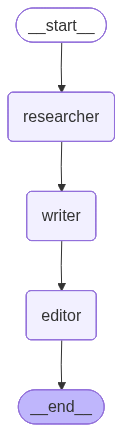

In [65]:
# Visualizing what we built
from IPython.display import Image, display

try:
    # This pulls the visual graph structure and displays it as a PNG image
    display(Image(app.get_graph().draw_mermaid_png()))
    
except Exception as e:
    print("Could not render the image directly. Here is the text version instead:\n")
    print(app.get_graph().draw_mermaid())

### Running the Assembly Code HERE, Inputs are HERE too!!

In [78]:
# Running this Agentic System

# 1. Feed the input
inputs = {
    'initial_topic': 'Who will win this years world cup and why, what are the odds, what do prediction markets and commentators think'
}

In [ ]:
# 2. Running this bad boy

final_state = app.invoke(inputs)
print('---- WORKFLOW COMPLETE ----')

#3. Retrieve the final draft

final_draft = final_state['final_draft']


AGENT 1: RESEARCHER IS WORKING
Searching the Web for relevant links
AGENT 2: WRITER IS WORKING
AGENT 3: EDITOR IS WORKING
---- WORFLOW COMPLETE ----


In [80]:
print(final_draft)

Introduction:
As excitement builds for the 2026 World Cup, fans worldwide are eagerly anticipating who will emerge victorious in this prestigious tournament. Spain is currently leading as the favorite to win, with strong contenders like the USA, Mexico, and Canada also in the running. But what factors are influencing these predictions, and what do prediction markets and commentators think about the potential outcome?

Body:
The odds currently favor Spain to win the 2026 World Cup, with a favorable rating of +450. However, other main contenders such as the USA, Mexico, and Canada are not far behind in the race for the coveted title. Predictions for the winner of the World Cup are heavily influenced by various factors including FIFA rankings, Elo ratings, historical tournament performance, squad depth analysis, and aggregated betting odds. These metrics provide a comprehensive overview of each team's strengths and weaknesses, shaping the predictions for the upcoming tournament.

The 2026

In [ ]:
# Simple Sequential Workflow, Now we could try to add loops etc to make it more robust!